In [ ]:
# =============================================================================
# INSTALL DREAMERV3 + CRAFTER STACK
# =============================================================================
!pip uninstall -y numpy jax jaxlib chex crafter embodied -q

!pip install numpy==1.26.4 -q
!pip install jax==0.4.33 jaxlib==0.4.33 -q
!pip install chex==0.1.87 -q

!pip install gym==0.26.2 -q
!pip install crafter==1.1.0 -q
!pip install opensimplex -q
!pip install elements -q

!rm -rf dreamerv3
!git clone https://github.com/danijar/dreamerv3.git

!pip install -e dreamerv3 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 94.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
flax 0.11.2 requires jax>=0.6.0, which is not installed.
orbax-checkpoint 0.12.0 requires jax>=0.6.0, which is not installed.
dopamine-rl 4.1.2 requires jax>=0.1.72, which is not installed.
dopamine-rl 4.1.2 requires jaxlib>=0.1.51, which is not installed.
optax 0.2.8 requires jax>=0.5.3, which is not installed.
optax 0.2.8 requires jaxlib>=0.5.3, which is not installed.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pyt

In [ ]:
import numpy as np
import jax

print("numpy =", np.__version__)
print("jax   =", jax.__version__)

numpy = 1.26.4
jax   = 0.4.33


In [ ]:
# If you are running on Google Colab, UNCOMMENT this block.
'''
# ── Google Drive mount ────────────────────────────────────────────────────────
from google.colab import drive
drive.mount("/content/drive")
'''

Mounted at /content/drive


In [ ]:
# =============================================================================
# EXTRACT TRAINED AGENT
# =============================================================================
import zipfile
import os

AGENT_ZIP = (
    "/content/drive/MyDrive/"
    "mbrl-testing-frameworks-empirical-study/"
    "agents/dreamerv3/crafter/"
    "crafter_full_complete.zip"
)

EXTRACT_ROOT = "/content/crafter_agent"

os.makedirs(
    EXTRACT_ROOT,
    exist_ok=True,
)

with zipfile.ZipFile(
    AGENT_ZIP,
    "r"
) as z:

    z.extractall(
        EXTRACT_ROOT
    )

print("✓ Agent extracted")

✓ Agent extracted


In [ ]:
import sys

sys.path.insert(0, "/content/dreamerv3")

import embodied
from dreamerv3.agent import Agent

print("✓ imports OK")

✓ imports OK


In [ ]:
from ruamel.yaml import YAML
import ruamel.yaml

def safe_load_patch(stream):
    y = YAML(typ="safe", pure=True)
    return y.load(stream)

ruamel.yaml.safe_load = safe_load_patch

try:
    import ruamel.yaml.main
    ruamel.yaml.main.safe_load = safe_load_patch
except:
    pass

print("✓ ruamel patched")

✓ ruamel patched


In [ ]:
import numpy as np
import opensimplex

if not hasattr(np, "bool"):
    np.bool = bool

if (
    not hasattr(opensimplex.OpenSimplex, "noise3d")
    and hasattr(opensimplex.OpenSimplex, "noise3")
):
    opensimplex.OpenSimplex.noise3d = (
        opensimplex.OpenSimplex.noise3
    )

print("✓ compatibility patches")

✓ compatibility patches


/tmp/ipykernel_23183/2088349663.py:4: FutureWarning: In the future `np.bool` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "bool"):


In [ ]:
# ==============================================================================
# FIX CRAFTER CONSTRUCTOR
# ==============================================================================

import crafter

# patch constructor only
if not hasattr(crafter.Env, "_orig_init"):

    crafter.Env._orig_init = crafter.Env.__init__

    def fixed_init(self, *args, **kwargs):

        kwargs.pop("reward", None)

        return self._orig_init(
            *args,
            **kwargs,
        )

    crafter.Env.__init__ = fixed_init

print("✓ Crafter constructor patched")

from embodied.envs.crafter import Crafter
import embodied

class CleanEnv(embodied.Wrapper):

    @property
    def obs_space(self):
        return {
            k: v
            for k, v in self.env.obs_space.items()
            if not k.startswith("log/")
        }

    @property
    def act_space(self):
        sp = dict(self.env.act_space)
        sp.pop("reset", None)
        return sp

    def step(self, action):

        action = dict(action)
        action.setdefault("reset", False)

        obs = self.env.step(action)

        # IMPORTANT
        if "reward" not in obs:
            obs["reward"] = 0.0

        return {
            k: v
            for k, v in obs.items()
            if not k.startswith("log/")
        }
# ==============================================================================
# PATCH DREAMER CRAFTER WRAPPER
# ==============================================================================

import embodied.envs.crafter as crafter_wrapper
import numpy as np

_orig_obs = crafter_wrapper.Crafter._obs

def patched_obs(
    self,
    image,
    reward,
    info,
    is_first,
    is_last,
    is_terminal,
):

    if info is None:
        info = {}

    if "reward" not in info:
        info["reward"] = float(reward)

    return {

        "image": image,

        "reward": np.float32(reward),

        "is_first": is_first,

        "is_last": is_last,

        "is_terminal": is_terminal,

        "log/reward":
            np.float32(
                info["reward"]
            ),
    }

crafter_wrapper.Crafter._obs = patched_obs

print("✓ Dreamer Crafter wrapper patched")
base_env = Crafter(
    task="reward",
    size=(64,64),
    logdir=None,
)

env = CleanEnv(base_env)

print("✓ Environment ready")

✓ Crafter constructor patched
✓ Dreamer Crafter wrapper patched
✓ Environment ready


In [ ]:
from ruamel.yaml import YAML
import elements

yaml = YAML(typ="safe")

CONFIG_PATH = (
    "/content/crafter_agent/"
    "crafter_full/config.yaml"
)

with open(CONFIG_PATH, "r") as f:
    raw = yaml.load(f)

flat = raw.copy()

for k, v in raw["agent"].items():
    flat[k] = v

config = elements.Config(flat)

print("✓ Config loaded")

✓ Config loaded


In [ ]:
from dreamerv3.agent import Agent

agent = Agent(
    env.obs_space,
    env.act_space,
    config,
)

print("✓ Agent built")

Observations
  image            Space(uint8, shape=(64, 64, 3), low=0, high=255)
  reward           Space(float32, shape=(), low=-inf, high=inf)
  is_first         Space(bool, shape=(), low=False, high=True)
  is_last          Space(bool, shape=(), low=False, high=True)
  is_terminal      Space(bool, shape=(), low=False, high=True)
Actions
  action           Space(int32, shape=(), low=0, high=17)
Extras
  consec           Space(int32, shape=(), low=-2147483648, high=2147483647)
  stepid           Space(uint8, shape=(20,), low=0, high=255)
  dyn/deter        Space(float32, shape=(8192,), low=-inf, high=inf)
  dyn/stoch        Space(float32, shape=(32, 64), low=-inf, high=inf)
JAX devices (1): [cuda:0]
Policy devices: cuda:0
Train devices:  cuda:0
Initializing parameters...
Optimizer opt has 165,965,075 params:
    95,495,168 dyn
    20,282,115 dec
    12,850,431 val
    12,606,481 pol
    10,749,183 rew
    10,488,833 con
     3,492,864 enc
Done initializing!
Compiling 1 checkpoint grou

In [ ]:
# ============================================================
# 🔥 CLEAN DREAMER + CRAFTER SETUP (FINAL WORKING VERSION)
# ============================================================

# ==============================
# 1. ruamel fix
# ==============================
from ruamel.yaml import YAML
import ruamel.yaml

def safe_load_patch(stream):
    y = YAML(typ='safe', pure=True)
    return y.load(stream)

ruamel.yaml.safe_load = safe_load_patch
try:
    import ruamel.yaml.main as _rym
    _rym.safe_load = safe_load_patch
except:
    pass

print("✅ ruamel.yaml patched")

# ==============================
# 2. numpy fix
# ==============================
import numpy as np

if not hasattr(np, "bool"):
    np.bool = bool

print("✅ numpy fixed")

# ==============================
# 3. imports
# ==============================
import os, jax
import embodied
from embodied.envs.crafter import Crafter
from dreamerv3.agent import Agent
import elements
import opensimplex

# 🔥 FIX: map noise3 → noise3d
if not hasattr(opensimplex.OpenSimplex, "noise3d"):
    opensimplex.OpenSimplex.noise3d = opensimplex.OpenSimplex.noise3

print("✅ OpenSimplex fixed")
print("✅ imports OK")

# ==========================================
# FORCE RESET Crafter.step (remove recursion)
# ==========================================

from embodied.envs.crafter import Crafter

# reload original class definition
import importlib
crafter_module = importlib.import_module("embodied.envs.crafter")
importlib.reload(crafter_module)

Crafter = crafter_module.Crafter
# ==============================
# 🔥 FIX Crafter constructor mismatch
# ==============================
import crafter

# store original constructor once
if not hasattr(crafter, "_orig_init"):
    crafter._orig_init = crafter.Env.__init__

def fixed_init(self, *args, **kwargs):
    kwargs.pop("reward", None)   # remove unsupported arg safely
    return crafter._orig_init(self, *args, **kwargs)

crafter.Env.__init__ = fixed_init

print("✅ Crafter constructor patched (safe)")

import crafter
import numpy as np

# 🔥 Patch the internal step → guarantee info['reward']


print("✅ Crafter step patched (FINAL)")
# ==========================================
# FINAL FIX — guarantee info["reward"] inside Crafter
# ==========================================

import crafter

_OrigEnv = crafter.Env

class PatchedCrafterEnv(_OrigEnv):
    def step(self, action):
        out = super().step(action)

        # normalize
        if isinstance(out, tuple) and len(out) == 5:
            obs, r, term, trunc, info = out
            done = term or trunc
        else:
            obs, r, done, info = out

        # 🔥 THIS is the real fix
        if info is None:
            info = {}

        if "reward" not in info:
            info["reward"] = float(r)

        return obs, r, done, info

# apply patch
crafter.Env = PatchedCrafterEnv

print("✅ Crafter reward bug fixed (REAL FIX)")
# ==============================
# 4. environment (NO hacks)
# ==============================
from embodied.envs.crafter import Crafter
import embodied

class CleanEnv(embodied.Wrapper):

    @property
    def obs_space(self):
        return {k: v for k, v in self.env.obs_space.items()
                if not k.startswith("log/")}

    @property
    def act_space(self):
        sp = dict(self.env.act_space)
        sp.pop("reset", None)
        return sp

    def step(self, action):
        action = dict(action)
        action.setdefault("reset", False)

        obs = self.env.step(action)

        # 🔥 CRITICAL FIX → KEEP reward alive
        if "reward" not in obs:
            obs["reward"] = 0.0

        return {k: v for k, v in obs.items()
                if not k.startswith("log/")}

# 🔥 IMPORTANT: wrap Crafter
base_env = Crafter(task="reward", size=(64,64))
env = CleanEnv(base_env)

print("✅ CleanEnv applied")

def safe_step(env, action):
    obs = env.step({"action": int(action), "reset": False})

    reward = float(obs["reward"])
    done = bool(obs["is_last"])

    return np.asarray(obs["image"], dtype=np.uint8), reward, done, obs

    # 🔥 CRITICAL FIX (must happen BEFORE anything else)
    if info is None:
        info = {}

    if "reward" not in info:
        info["reward"] = float(r)

    return np.asarray(obs, dtype=np.uint8), float(r), bool(done), info

def safe_reset(env, seed=None):
    obs = env.step({"action": 0, "reset": True})

    if isinstance(obs, dict):
        image = obs.get("image", obs)
        info = obs
    else:
        image = obs
        info = {}

    if "reward" not in info:
        info["reward"] = 0.0

    return np.asarray(image, dtype=np.uint8), info
# ==============================
# 5. config
# ==============================
yaml = YAML(typ='safe')

with open("/content/crafter_agent/crafter_full/config.yaml", "r") as f:
    raw = yaml.load(f)

flat = raw.copy()
for k, v in raw.get("agent", {}).items():
    flat[k] = v

config = elements.Config(flat)

print("✅ config loaded")

# ==============================
# 6. agent
# ==============================
agent = Agent(env.obs_space, env.act_space, config)

CKPT_ROOT = "/content/crafter_agent/crafter_full/ckpt"

subdirs = [
    os.path.join(CKPT_ROOT, d)
    for d in os.listdir(CKPT_ROOT)
    if os.path.isdir(os.path.join(CKPT_ROOT, d)) and d != "latest"
]

ckpt_path = sorted(subdirs)[-1]

ckpt = elements.Checkpoint()
ckpt.agent = agent
ckpt.load(ckpt_path)

print("✅ Agent loaded:", ckpt_path)

# ==============================
# 7. TEST (Dreamer-native)
# ==============================
def quick_test():

    obs = env.step({"action": 0, "reset": True})
    obs = {k: np.expand_dims(v, 0) for k, v in obs.items()}

    carry = agent.init_policy(batch_size=1)

    total_reward = 0.0

    for _ in range(50):

        carry, acts, _ = agent.policy(carry, obs, mode="eval")

        action = {k: v[0] for k, v in acts.items()}

        obs = env.step(action)
        total_reward += float(obs["reward"])

        obs = {k: np.expand_dims(v, 0) for k, v in obs.items()}

        if obs["is_last"]:
            break

    print("✔ OK → reward:", total_reward)

quick_test()

✅ ruamel.yaml patched
✅ numpy fixed
✅ OpenSimplex fixed
✅ imports OK
✅ Crafter constructor patched (safe)
✅ Crafter step patched (FINAL)
✅ Crafter reward bug fixed (REAL FIX)
✅ CleanEnv applied
✅ config loaded
Observations
  image            Space(uint8, shape=(64, 64, 3), low=0, high=255)
  reward           Space(float32, shape=(), low=-inf, high=inf)
  is_first         Space(bool, shape=(), low=False, high=True)
  is_last          Space(bool, shape=(), low=False, high=True)
  is_terminal      Space(bool, shape=(), low=False, high=True)
Actions
  action           Space(int32, shape=(), low=0, high=17)
Extras
  consec           Space(int32, shape=(), low=-2147483648, high=2147483647)
  stepid           Space(uint8, shape=(20,), low=0, high=255)
  dyn/deter        Space(float32, shape=(8192,), low=-inf, high=inf)
  dyn/stoch        Space(float32, shape=(32, 64), low=-inf, high=inf)
JAX devices (1): [cuda:0]
Policy devices: cuda:0
Train devices:  cuda:0
Initializing parameters...
Optimiz

In [ ]:
import os
import elements

CKPT_ROOT = (
    "/content/crafter_agent/"
    "crafter_full/ckpt"
)

subdirs = [
    os.path.join(CKPT_ROOT, d)
    for d in os.listdir(CKPT_ROOT)
    if os.path.isdir(os.path.join(CKPT_ROOT, d))
    and d != "latest"
]

ckpt_path = sorted(subdirs)[-1]

print("Loading:", ckpt_path)

ckpt = elements.Checkpoint()
ckpt.agent = agent
ckpt.load(ckpt_path)

print("✓ Agent loaded")

Loading: /content/crafter_agent/crafter_full/ckpt/20260214T194058F926616
Loading checkpoint: /content/crafter_agent/crafter_full/ckpt/20260214T194058F926616
Loaded checkpoint.
✓ Agent loaded


In [ ]:
quick_test()

✔ OK → reward: 7.0


## **TCP**

In [ ]:
# =============================================================================
# PATHS
# =============================================================================
from pathlib import Path

# for faster run NUM_RUNS=1, EPISODE_BUDGET= 100. for paper results replication, set (NUM_RUNS=10, EPISODE_BUDGET= 1500)
NUM_RUNS = 1
EPISODE_BUDGET = 100

MASTER_SEED = 42
BASE_SEED_START = 5000

ROOT = Path(
    "/content/drive/MyDrive/mbrl-testing-frameworks-empirical-study"
)

RESULTS_DIR = (
    ROOT
    / "results"
    / "Crafter"
)

RAW_DIR = RESULTS_DIR / "raw"
TABLES_DIR = RESULTS_DIR / "tables"
FIGS_DIR = RESULTS_DIR / "figs"

for p in [
    RESULTS_DIR,
    RAW_DIR,
    TABLES_DIR,
    FIGS_DIR,
]:
    p.mkdir(
        parents=True,
        exist_ok=True,
    )
print("Results:", RESULTS_DIR)

Results: /content/drive/MyDrive/mbrl-testing-frameworks-empirical-study/results/Crafter


In [ ]:
# ==============================================================================
# DREAMER INFERENCE WRAPPERS
# ==============================================================================

from typing import Any, Tuple

ACTION_SPACE = 17

def dreamer_reset_carry(
    batch_size: int = 1,
):
    return agent.init_policy(
        batch_size=batch_size
    )


def dreamer_step(
    carry,
    obs_np: np.ndarray,
    reward: float = 0.0,
    is_first: bool = False,
    is_last: bool = False,
):

    obs_dict = {

        "image":
            obs_np[None, ...].astype(
                np.uint8
            ),

        "reward":
            np.array(
                [float(reward)],
                dtype=np.float32,
            ),

        "is_first":
            np.array([bool(is_first)]),

        "is_last":
            np.array([bool(is_last)]),

        "is_terminal":
            np.array([False]),
    }

    carry_next, acts, outs = (
        agent.policy(
            carry,
            obs_dict,
            mode="eval",
        )
    )

    action = int(
        acts["action"][0]
    )

    logits = (
        jax.device_get(
            outs["logits"][0]
        ).astype(np.float32)

        if "logits" in outs

        else np.zeros(
            ACTION_SPACE,
            dtype=np.float32,
        )
    )

    return (
        carry_next,
        action,
        logits,
        outs,
    )


def extract_latent(
    carry,
):

    latent = carry[1]

    deter = (
        jax.device_get(
            latent["deter"][0]
        )
        .reshape(-1)
    )

    stoch = (
        jax.device_get(
            latent["stoch"][0]
        )
        .reshape(-1)
    )

    return np.concatenate(
        [
            deter,
            stoch,
        ]
    ).astype(np.float32)

print("✓ Dreamer wrappers ready")

✓ Dreamer wrappers ready


In [ ]:
# ==============================================================================
# ENVIRONMENT HELPERS
# ==============================================================================

def make_crafter_env(
    seed=None,
):

    base = Crafter(
        task="reward",
        size=(64,64),
        logdir=None,
    )

    env = CleanEnv(base)

    if seed is not None:

        try:
            env.env.seed(
                int(seed)
            )
        except:
            pass

    return env


def safe_reset(
    env,
    seed=None,
):

    obs = env.step({
        "action": 0,
        "reset": True,
    })

    return (
        np.asarray(
            obs["image"],
            dtype=np.uint8,
        ),
        {},
    )


def safe_step(
    env,
    action,
):

    obs = env.step({
        "action": int(action),
        "reset": False,
    })

    reward = float(
        obs["reward"]
    )

    done = bool(
        obs["is_last"]
    )

    return (
        np.asarray(
            obs["image"],
            dtype=np.uint8,
        ),
        reward,
        done,
        obs,
    )


def safe_close(
    env,
):

    try:
        env.close()
    except:
        pass

print("✓ Environment helpers ready")

✓ Environment helpers ready


In [ ]:
# ==============================================================================
# FAILURE ORACLE
# ==============================================================================

MAX_STEPS_DEFAULT = 500

STALL_WINDOW0 = 50
STALL_MIN_DO0 = 1

STALL_WINDOW = 100
STALL_MIN_DO = 2

STALL_WINDOW2 = 200
STALL_MIN_DO2 = 3

DO_ACTION = 0

FAILURE_THRESHOLD = 5.0


def calibrate_failure_threshold(
    pool,
    percentile=30,
):

    returns = [
        ep["return"]
        for ep in pool
    ]

    return float(
        np.percentile(
            returns,
            percentile,
        )
    )


def _stall_failed(
    t,
    do_count,
    hit_positive,
):

    if (
        t >= STALL_WINDOW0
        and do_count < STALL_MIN_DO0
        and not hit_positive
    ):
        return True

    if (
        t >= STALL_WINDOW
        and do_count < STALL_MIN_DO
        and not hit_positive
    ):
        return True

    if (
        t >= STALL_WINDOW2
        and do_count < STALL_MIN_DO2
    ):
        return True

    return False


def failure_oracle_crafter(
    cum_rew,
    t,
    done,
    info,
):

    if (
        done
        or t >= MAX_STEPS_DEFAULT
    ):
        return (
            cum_rew
            < FAILURE_THRESHOLD
        )

    return False

print("✓ Oracle ready")

✓ Oracle ready


In [ ]:
# ==============================================================================
# EPISODE RUNNER
# ==============================================================================

def run_episode(
    seed: int,
    p_rand: float = 0.25,
):

    env = make_crafter_env(
        seed=int(seed)
    )

    obs, _ = safe_reset(
        env,
        seed=int(seed),
    )

    carry = dreamer_reset_carry()

    cum_reward = 0.0

    t = 0

    do_count = 0
    hit_positive = False

    reward_buf = 0.0
    is_first = True

    rng = np.random.default_rng(
        int(seed)
    )

    t0 = time.perf_counter()

    while True:

        carry, action, logits, outs = (
            dreamer_step(
                carry,
                obs,
                reward=reward_buf,
                is_first=is_first,
            )
        )

        is_first = False

        if rng.random() < p_rand:

            action = int(
                rng.integers(
                    0,
                    ACTION_SPACE,
                )
            )

        if action == DO_ACTION:
            do_count += 1

        obs, reward, done, info = (
            safe_step(
                env,
                action,
            )
        )

        cum_reward += reward

        t += 1

        reward_buf = reward

        if reward > 0:
            hit_positive = True

        if _stall_failed(
            t,
            do_count,
            hit_positive,
        ):
            break

        if done:
            break

        if t >= MAX_STEPS_DEFAULT:
            break

    elapsed = (
        time.perf_counter()
        - t0
    )

    safe_close(env)

    return {

        "episode_id": 0,

        "seed":
            int(seed),

        "initial_state":
            int(seed),

        "return":
            float(cum_reward),

        "steps":
            int(t),

        "time":
            float(elapsed),
    }


def ensure_seed(pool):

    for i, ep in enumerate(pool):

        if "seed" not in ep:

            ep["seed"] = int(
                ep.get(
                    "initial_state",
                    i,
                )
            )

    return pool


print("✓ Episode runner ready")

✓ Episode runner ready


In [ ]:
# ==============================================================================
# POOL GENERATION
# ==============================================================================

FAILURE_THRESHOLD = 5.0


def generate_pool(
    base_seed: int,
    budget: int = EPISODE_BUDGET,
):

    global FAILURE_THRESHOLD

    pool = []

    for i in tqdm(
        range(budget),
        desc="Generating Pool",
        leave=False,
    ):

        seed = int(
            base_seed + i
        )

        result = run_episode(
            seed=seed
        )

        pool.append({

            "episode_id": i,

            "seed":
                seed,

            "initial_state":
                seed,

            "time":
                result["time"],

            "return":
                result["return"],

            "steps":
                result["steps"],
        })

    FAILURE_THRESHOLD = (
        calibrate_failure_threshold(
            pool,
            percentile=30,
        )
    )

    for ep in pool:

        ep["failure"] = int(
            ep["return"]
            < FAILURE_THRESHOLD
        )

    return pool


print("✓ Pool generation ready")

✓ Pool generation ready


In [ ]:
# ==============================================================================
# SIGNAL EXTRACTION
# ==============================================================================

SIGNAL_ROLLOUT_STEPS = 8

SIGNAL_CACHE = {}


def extract_signals_from_seed(seed: int):

    if seed in SIGNAL_CACHE:
        return SIGNAL_CACHE[seed]

    env = make_crafter_env(
        seed=int(seed)
    )

    obs, _ = safe_reset(
        env,
        seed=int(seed),
    )

    carry = dreamer_reset_carry()

    entropies = []
    margins = []
    confidences = []

    latent_vecs = []

    rewards = []

    early_rewards = []

    cum_reward_partial = 0.0

    reward_buf = 0.0

    is_first = True

    for _ in range(
        SIGNAL_ROLLOUT_STEPS
    ):

        carry, action, logits, outs = (
            dreamer_step(
                carry,
                obs,
                reward=reward_buf,
                is_first=is_first,
            )
        )

        is_first = False

        # --------------------------------
        # POLICY SIGNALS
        # --------------------------------

        lmax = logits - np.max(logits)

        probs = (
            np.exp(lmax)
            /
            (
                np.sum(np.exp(lmax))
                + 1e-12
            )
        )

        entropies.append(
            float(
                -np.sum(
                    probs
                    *
                    np.log(
                        probs
                        + 1e-12
                    )
                )
            )
        )

        confidences.append(
            float(
                np.max(probs)
            )
        )

        sorted_probs = np.sort(probs)

        margins.append(
            float(
                sorted_probs[-1]
                -
                sorted_probs[-2]
            )
        )

        # --------------------------------
        # LATENT SIGNALS
        # --------------------------------

        z = extract_latent(
            carry
        )

        latent_vecs.append(z)

        # --------------------------------
        # ENV STEP
        # --------------------------------

        obs, reward_buf, done, _ = (
            safe_step(
                env,
                action,
            )
        )

        rewards.append(
            reward_buf
        )

        cum_reward_partial += (
            reward_buf
        )

        if len(
            early_rewards
        ) < 5:

            early_rewards.append(
                reward_buf
            )

        if done:
            break

    safe_close(env)

    # --------------------------------
    # DELTA-Z
    # --------------------------------

    if len(latent_vecs) > 1:

        delta_z = np.mean([

            np.linalg.norm(
                latent_vecs[i]
                -
                latent_vecs[i - 1]
            )

            for i in range(
                1,
                len(latent_vecs)
            )
        ])

    else:

        delta_z = 0.0

    latent_norm = (
        np.mean([
            np.linalg.norm(z)
            for z in latent_vecs
        ])
        if latent_vecs
        else 0.0
    )

    mean_latent = (
        np.mean(
            latent_vecs,
            axis=0,
        )
        if latent_vecs
        else np.zeros(1)
    )

    result = {

        # policy

        "Entropy":
            np.mean(entropies)
            if entropies
            else 0.0,

        "Margin":
            np.mean(margins)
            if margins
            else 0.0,

        "Confidence":
            np.mean(confidences)
            if confidences
            else 0.0,

        # latent

        "LatentNorm":
            latent_norm,

        "DeltaZ":
            delta_z,

        "_mean_latent":
            mean_latent,

        # trajectory

        "Steps":
            len(rewards),

        "PartialReturn":
            cum_reward_partial,

        "EarlyReward":
            np.sum(early_rewards)
            if early_rewards
            else 0.0,

        "RewardVar":
            np.var(rewards)
            if rewards
            else 0.0,
    }

    SIGNAL_CACHE[
        seed
    ] = result

    return result


def attach_signals(pool):

    for ep in tqdm(
        pool,
        desc="Extracting signals",
        leave=False,
    ):

        sigs = extract_signals_from_seed(
            ep["seed"]
        )

        ep.update(sigs)

    return pool


def compute_latent_centroid(pool):

    vecs = [

        ep["_mean_latent"]

        for ep in pool

        if "_mean_latent" in ep
    ]

    return (
        np.mean(
            vecs,
            axis=0,
        )
        if vecs
        else np.zeros(1)
    )


def attach_latent_novelty(
    pool,
    centroid,
):

    for ep in pool:

        mean_z = ep.get(
            "_mean_latent",
            np.zeros_like(
                centroid
            ),
        )

        ep["LatentNovelty"] = (
            float(
                np.linalg.norm(
                    mean_z
                    -
                    centroid
                )
            )
        )

    return pool


print("✓ Signal extraction ready")

✓ Signal extraction ready


In [ ]:
# ==============================================================================
# METRICS ENGINE
# ==============================================================================

def compute_metrics(
    results_df,
    TCP_time=0.0,
):

    failures = (
        results_df["failure"]
        .values
        .astype(int)
    )

    times = (
        results_df["time"]
        .values
        .astype(float)
    )

    n = len(failures)

    total_failures = int(
        np.sum(failures)
    )

    FR = (
        total_failures / n
        if n > 0
        else np.nan
    )

    if total_failures > 0:

        first_idx = int(
            np.where(
                failures == 1
            )[0][0]
        )

        TTF_tests = (
            first_idx + 1
        )

        TTF_time = float(
            np.sum(
                times[
                    :first_idx + 1
                ]
            )
        )

    else:

        TTF_tests = np.nan
        TTF_time = np.nan

    if total_failures > 0:

        positions = (
            np.where(
                failures == 1
            )[0]
            + 1
        )

        APFD = float(
            1.0
            -
            (
                np.sum(positions)
                /
                (
                    n
                    * total_failures
                )
            )
            +
            (
                1.0
                /
                (
                    2.0 * n
                )
            )
        )

    else:

        APFD = np.nan

    if total_failures > 0:

        cum_time = np.cumsum(
            times
        )

        fail_times = cum_time[
            np.where(
                failures == 1
            )[0]
        ]

        total_time = cum_time[-1]

        APFD_time = float(
            1.0
            -
            (
                np.sum(fail_times)
                /
                (
                    total_time
                    * total_failures
                )
            )
            +
            (
                1.0
                /
                (
                    2.0 * total_time
                )
            )
        )

    else:

        APFD_time = np.nan

    return {

        "FR": FR,

        "TTF_tests":
            TTF_tests,

        "TTF_time":
            TTF_time,

        "APFD":
            APFD,

        "APFD_time":
            APFD_time,

        "TCP_time":
            TCP_time,

        "Per_test_overhead":
            TCP_time / n
            if n > 0
            else np.nan,
    }

print("✓ Metrics engine ready")

✓ Metrics engine ready


In [ ]:
# ==============================================================================
# TCP METHODS
# ==============================================================================

def TCP_fifo(pool, **_):
    return sorted(
        pool,
        key=lambda x:
        x["episode_id"]
    )

def TCP_random(
    pool,
    seed=42,
    **_,
):
    rng = np.random.default_rng(
        seed
    )

    shuffled = pool.copy()

    rng.shuffle(
        shuffled
    )

    return shuffled


# ------------------------------------------------------------------
# Policy
# ------------------------------------------------------------------

def TCP_entropy(pool, **_):
    return sorted(
        pool,
        key=lambda x:
        x["Entropy"],
        reverse=True,
    )

def TCP_margin(pool, **_):
    return sorted(
        pool,
        key=lambda x:
        x["Margin"],
    )

def TCP_confidence(pool, **_):
    return sorted(
        pool,
        key=lambda x:
        x["Confidence"],
    )


# ------------------------------------------------------------------
# Latent
# ------------------------------------------------------------------

def TCP_latent_norm(pool, **_):
    return sorted(
        pool,
        key=lambda x:
        x["LatentNorm"],
        reverse=True,
    )

def TCP_delta_z(pool, **_):
    return sorted(
        pool,
        key=lambda x:
        x["DeltaZ"],
        reverse=True,
    )

def TCP_latent_novelty(pool, **_):
    return sorted(
        pool,
        key=lambda x:
        x["LatentNovelty"],
        reverse=True,
    )


# ------------------------------------------------------------------
# Trajectory
# ------------------------------------------------------------------

def TCP_steps(pool, **_):
    return sorted(
        pool,
        key=lambda x:
        x["Steps"]
    )

def TCP_partial_return(pool, **_):
    return sorted(
        pool,
        key=lambda x:
        x["PartialReturn"]
    )

def TCP_early_reward(pool, **_):
    return sorted(
        pool,
        key=lambda x:
        x["EarlyReward"]
    )

def TCP_reward_var(pool, **_):
    return sorted(
        pool,
        key=lambda x:
        x["RewardVar"],
        reverse=True,
    )

def TCP_hybrid_delta_reward(pool, **_):
    return sorted(
        pool,
        key=lambda x:
        x["DeltaZ"]
        -
        x["RewardVar"],
        reverse=True,
    )


TCP_REGISTRY = {

    "FIFO":
        TCP_fifo,

    "Random":
        TCP_random,

    "Entropy":
        TCP_entropy,

    "Margin":
        TCP_margin,

    "Confidence":
        TCP_confidence,

    "LatentNorm":
        TCP_latent_norm,

    "DeltaZ":
        TCP_delta_z,

    "LatentNovelty":
        TCP_latent_novelty,

    "Steps":
        TCP_steps,

    "PartialReturn":
        TCP_partial_return,

    "EarlyReward":
        TCP_early_reward,

    "RewardVar":
        TCP_reward_var,

    "Hybrid_DeltaZ_RewardVar":
        TCP_hybrid_delta_reward,
}

print("✓ TCP methods ready")

✓ TCP methods ready


In [ ]:
# ==============================================================================
# TCP APPLICATION + EVALUATION
# ==============================================================================

def apply_TCP(
    pool,
    TCP_name,
    run_seed=42,
):

    func = TCP_REGISTRY[
        TCP_name
    ]

    t0 = time.perf_counter()

    if TCP_name == "Random":

        ordered = func(
            pool,
            seed=run_seed,
        )

    else:

        ordered = func(
            pool
        )

    tcp_time = (
        time.perf_counter()
        - t0
    )

    return (
        ordered,
        tcp_time,
    )


def evaluate_ordered_pool(
    ordered_pool,
    TCP_time,
):

    rows = []

    for ep in ordered_pool:

        rows.append({

            "failure":
                int(
                    ep["failure"]
                ),

            "time":
                float(
                    ep["time"]
                ),
        })

    df = pd.DataFrame(
        rows
    )

    metrics = compute_metrics(
        df,
        TCP_time=TCP_time,
    )

    return (
        df,
        metrics,
    )

print("✓ Evaluation ready")

✓ Evaluation ready


In [ ]:
# ==============================================================================
# PHASE 1
# ==============================================================================



def run_single_experiment(
    base_seed,
    run_id,
):

    print(
        f"Generating pool "
        f"(seed={base_seed})"
    )

    SIGNAL_CACHE.clear()

    pool = generate_pool(
        base_seed,
        EPISODE_BUDGET,
    )

    pool = attach_signals(
        pool
    )

    centroid = (
        compute_latent_centroid(
            pool
        )
    )

    pool = attach_latent_novelty(
        pool,
        centroid,
    )

    rows = []

    for TCP_name in TCP_REGISTRY:

        ordered, tcp_time = (
            apply_TCP(
                pool,
                TCP_name,
                run_seed=base_seed,
            )
        )

        df, metrics = (
            evaluate_ordered_pool(
                ordered,
                tcp_time,
            )
        )

        row = {

            "run_id":
                run_id,

            "TCP":
                TCP_name,
        }

        row.update(
            metrics
        )

        rows.append(
            row
        )

        print(
            f"{TCP_name:<25}"
            f"APFD={metrics['APFD']:.4f}"
        )

    return rows


def run_phase1():

    all_rows = []

    for run_id in range(
        NUM_RUNS
    ):

        base_seed = (
            BASE_SEED_START
            +
            run_id * 10000
        )

        rows = (
            run_single_experiment(
                base_seed,
                run_id,
            )
        )

        all_rows.extend(
            rows
        )

    results = pd.DataFrame(
        all_rows
    )

    return results

print("✓ Phase 1 ready")

✓ Phase 1 ready


In [ ]:
# ------------------------------------------------------------
# FRAMEWORK GENERATORS
# ------------------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier   # 🔥 ADD THIS

NR_RL_P_RAND = 0.25
def generate_tests_indago(base_seed, budget):

    pool_size = 3 * budget
    train_size = budget

    # 1. candidate pool
    pool = generate_pool(base_seed, pool_size)
    pool = attach_signals(pool)

    # 2. training data
    X = np.array([
        [
            t["steps"],
            t["PartialReturn"],
            t["EarlyReward"],
            t["DeltaZ"],
            t["RewardVar"]
        ]
        for t in pool[:train_size]
    ])

    y = np.array([t["failure"] for t in pool[:train_size]])

    clf = RandomForestClassifier(n_estimators=100)
    clf.fit(X, y)

    # 3. score entire pool
    X_all = np.array([
        [
            t["steps"],
            t["PartialReturn"],
            t["EarlyReward"],
            t["DeltaZ"],
            t["RewardVar"]
        ]
        for t in pool
    ])

    scores = clf.predict_proba(X_all)[:, 1]

    idx = np.argsort(scores)[::-1][:budget]

    return [pool[i] for i in idx]


def generate_tests_starla(base_seed, budget):

    rng = np.random.default_rng(base_seed)

    population = generate_pool(base_seed, 50)
    population = attach_signals(population)

    archive = {}

    for _ in range(10):

        for t in population:

            # ✔ scalar fitness per individual (NOT list)
            fit = (
                -abs(t["return"] - FAILURE_THRESHOLD)   # push to boundary
                + 0.5 * t["RewardVar"]
                + 0.3 * t["DeltaZ"]
            )

            bd = (
                int(t["steps"] // 20),
                int(t["RewardVar"] * 10)
            )

            if bd not in archive or fit > archive[bd]["fitness"]:
                archive[bd] = {"fitness": fit, "ep": t}

        # diversity sampling
        parents = [archive[k]["ep"] for k in archive]

        offspring = []
        for p in parents:
            new_seed = int(p["seed"] + rng.integers(-200, 200))
            child = run_episode(new_seed)
            offspring.append(child)

        population = attach_signals(offspring)

        if len(archive) >= budget:
            break

    return [archive[k]["ep"] for k in list(archive)[:budget]]

def generate_tests_qd(base_seed, budget):

    archive = {}
    pool = []

    while len(pool) < budget:

        ep = run_episode(base_seed + len(pool))
        ep = attach_signals([ep])[0]

        # behavior descriptor
        bd = (
            int(ep["steps"] // 20),
            int(ep["RewardVar"] * 10)
        )

        failure = int(ep["return"] < FAILURE_THRESHOLD)
        score = (failure, -ep["steps"])
        if bd not in archive or score > archive[bd]["score"]:
            archive[bd] = {"score": score, "ep": ep}

        # mutate from archive
        parent = list(archive.values())[np.random.randint(len(archive))]
        new_seed = parent["ep"]["seed"] + np.random.randint(-100,100)

        ep2 = run_episode(new_seed)
        ep2 = attach_signals([ep2])[0]
        pool.append(ep2)

    return pool

def generate_tests_rlmutation(base_seed, budget):

    rng = np.random.default_rng(base_seed)
    pool = []

    for i in range(budget):

        seed = base_seed + i

        # mutate seed (input-level mutation)
        if rng.random() < 0.5:
            seed += rng.integers(-200, 200)

        ep = run_episode(seed)

        pool.append(ep)

    return pool


def generate_tests_mdpfuzz(base_seed, budget):

    rng = np.random.default_rng(base_seed)

    corpus = generate_pool(base_seed, 50)
    corpus = attach_signals(corpus)

    pool = []

    while len(pool) < budget:

        parent = corpus[rng.integers(len(corpus))]

        new_seed = int(parent["seed"] + rng.integers(-300, 300)) % (2**32)
        ep = run_episode(new_seed)

        failure = int(ep["return"] < FAILURE_THRESHOLD)

        pool.append(ep)

        # coverage: keep failures
        if failure:
            corpus.append(ep)

    return pool


def generate_tests_nrrl(base_seed, budget):

    rng = np.random.default_rng(base_seed)
    pool = []

    for i in range(budget):
        seed = base_seed + i

        ep = run_episode(seed, p_rand=NR_RL_P_RAND)  # ✔ inject randomness

        pool.append(ep)

    return pool


FRAMEWORKS = {
    "Indago": generate_tests_indago,
    "STARLA": generate_tests_starla,
    "QD": generate_tests_qd,
    "RLMutation": generate_tests_rlmutation,
    "MDPFuzz": generate_tests_mdpfuzz,
    "NR-RL": generate_tests_nrrl,
}

In [ ]:
# ==============================================================================
#  FRAMEWORK EVALUATION
# ==============================================================================

def run_framework_phase():

    all_rows = []

    for run_id in range(NUM_RUNS):

        base_seed = (
            BASE_SEED_START
            + run_id * 10000
        )

        print("\n" + "=" * 60)
        print(
            f"RUN {run_id+1}/{NUM_RUNS}"
        )
        print("=" * 60)

        for fw_name, gen_fn in FRAMEWORKS.items():

            print(
                f"\n[{fw_name}] generating pool..."
            )

            SIGNAL_CACHE.clear()

            fw_seed = (
                base_seed
                +
                abs(hash(fw_name))
                % 10000
            )

            pool = gen_fn(
                fw_seed,
                EPISODE_BUDGET,
            )

            # ensure labels

            for ep in pool:

                if "failure" not in ep:

                    ep["failure"] = int(
                        ep["return"]
                        <
                        FAILURE_THRESHOLD
                    )

            for i, ep in enumerate(pool):

                ep["episode_id"] = i

                ep["seed"] = int(
                    ep.get(
                        "seed",
                        fw_seed + i,
                    )
                )

            pool = attach_signals(
                pool
            )

            centroid = (
                compute_latent_centroid(
                    pool
                )
            )

            pool = (
                attach_latent_novelty(
                    pool,
                    centroid,
                )
            )

            for TCP_name in TCP_REGISTRY:

                ordered, tcp_time = (
                    apply_TCP(
                        pool,
                        TCP_name,
                        run_seed=fw_seed,
                    )
                )

                df, metrics = (
                    evaluate_ordered_pool(
                        ordered,
                        tcp_time,
                    )
                )

                row = {

                    "run_id":
                        run_id,

                    "framework":
                        fw_name,

                    "TCP":
                        TCP_name,
                }

                row.update(
                    metrics
                )

                all_rows.append(
                    row
                )

                print(
                    f"{fw_name:<12}"
                    f"{TCP_name:<25}"
                    f"APFD={metrics['APFD']:.4f}"
                )

    return pd.DataFrame(
        all_rows
    )

print("✓ Framework evaluation ready")

✓ Framework evaluation ready


In [ ]:
SIGNAL_ROLLOUT_STEPS = 8
import os
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from typing import Dict, Any, List, Tuple
from time import perf_counter
from scipy.stats import mannwhitneyu

dict_keys(['episode_id', 'seed', 'initial_state', 'time', 'return', 'steps', 'failure', 'Entropy', 'Margin', 'Confidence', 'LatentNorm', 'DeltaZ', '_mean_latent', 'Steps', 'PartialReturn', 'EarlyReward', 'RewardVar'])


In [ ]:
# ==============================================================================
#  PLOT CONFIG
# ==============================================================================

TCP_ORDER = [
    "FIFO",
    "Random",
    "Entropy",
    "Margin",
    "Confidence",
    "LatentNorm",
    "DeltaZ",
    "LatentNovelty",
    "Steps",
    "PartialReturn",
    "EarlyReward",
    "RewardVar",
    "Hybrid_DeltaZ_RewardVar",
]

TCP_COLOR_MAP = {

    "FIFO": "#4D4D4D",
    "Random": "#9E9E9E",

    "Entropy": "#1F77B4",
    "Margin": "#17BECF",
    "Confidence": "#2CA02C",

    "LatentNorm": "#9467BD",
    "DeltaZ": "#E377C2",
    "LatentNovelty": "#FF7F0E",

    "Steps": "#8C564B",
    "PartialReturn": "#BCBD22",
    "EarlyReward": "#7F7F7F",

    "RewardVar": "#D62728",

    "Hybrid_DeltaZ_RewardVar":
        "#00B5AD",
}

print("✓ Plot config ready")


def save_plot(name):

    plt.savefig(
        FIGS_DIR / f"{name}.pdf",
        bbox_inches="tight",
    )

    plt.savefig(
        FIGS_DIR / f"{name}.png",
        dpi=300,
        bbox_inches="tight",
    )


def plot_phase1_apfd(agg):

    plt.figure(figsize=(6,3))

    ordered = (
        agg
        .set_index("TCP")
        .reindex(TCP_ORDER)
    )

    plt.bar(
        ordered.index,
        ordered["APFD_mean"],
        color=[
            TCP_COLOR_MAP[t]
            for t in ordered.index
        ],
        edgecolor="black",
        linewidth=0.5,
    )

    plt.ylabel("APFD")
    plt.title("Crafter Phase 1")

    plt.xticks(
        rotation=35,
        ha="right",
    )

    plt.tight_layout()

    save_plot("phase1_apfd")

    plt.show()


def plot_phase2_apfd(agg):

    frameworks = agg["framework"].unique()

    fig, axes = plt.subplots(
        1,
        len(frameworks),
        figsize=(4 * len(frameworks), 3),
        sharey=True,
    )

    if len(frameworks) == 1:
        axes = [axes]

    for ax, framework in zip(
        axes,
        frameworks,
    ):

        subset = (
            agg[
                agg["framework"] == framework
            ]
            .set_index("TCP")
            .reindex(TCP_ORDER)
        )

        ax.bar(
            subset.index,
            subset["APFD_mean"],
            color=[
                TCP_COLOR_MAP[t]
                for t in subset.index
            ],
            edgecolor="black",
            linewidth=0.5,
        )

        ax.set_title(framework)

        ax.tick_params(
            axis="x",
            rotation=40,
        )

    plt.tight_layout()

    save_plot("phase2_apfd")

    plt.show()


def plot_phase2_overhead(agg):

    frameworks = agg["framework"].unique()

    fig, axes = plt.subplots(
        1,
        len(frameworks),
        figsize=(4 * len(frameworks), 3),
        sharey=True,
    )

    if len(frameworks) == 1:
        axes = [axes]

    for ax, framework in zip(
        axes,
        frameworks,
    ):

        subset = (
            agg[
                agg["framework"] == framework
            ]
            .set_index("TCP")
            .reindex(TCP_ORDER)
        )
        ax.bar(
            subset.index,
            subset["TCP_time_mean"],
            color=[
                TCP_COLOR_MAP[t]
                for t in subset.index
            ],
            edgecolor="black",
            linewidth=0.5,
        )

        ax.set_title(framework)

        ax.tick_params(
            axis="x",
            rotation=40,
        )

    plt.tight_layout()

    save_plot("phase2_overhead")

    plt.show()

✓ Plot config ready


In [ ]:
# =============================================================================
# PHASE 2 — FRAMEWORK-INTEGRATED TCP
# =============================================================================
# =============================================================================
# PHASE 1 SUMMARY
# =============================================================================

def summarize_phase1(
    results,
):

    metrics = [

        "FR",
        "TTF_tests",
        "TTF_time",
        "APFD",
        "APFD_time",
        "TCP_time",
        "Per_test_overhead",
    ]

    agg = (

        results

        .groupby("TCP")[metrics]

        .agg(
            ["mean", "std"]
        )

        .round(6)
    )

    agg.columns = [

        "_".join(col)

        for col in agg.columns
    ]

    agg = agg.reset_index()

    agg.to_csv(
        TABLES_DIR /
        "phase1_aggregate.csv",
        index=False,
    )

    return agg

def run_phase2_single_run(
    run_id,
    base_seed,
):

    print(
        f"\nPhase 2 | Run {run_id + 1} "
        f"(seed={base_seed})"
    )

    rows = []

    for framework_name, generator in FRAMEWORKS.items():

        print(
            f"\n[{framework_name}] Generating test pool..."
        )

        start = time.perf_counter()

        pool = generator(
            base_seed=base_seed,
            budget=EPISODE_BUDGET,
        )

        generation_time = (
            time.perf_counter()
            - start
        )

        # ----------------------------------
        # ensure signal availability
        # ----------------------------------

        pool = attach_signals(
            pool
        )

        centroid = (
            compute_latent_centroid(
                pool
            )
        )

        pool = attach_latent_novelty(
            pool,
            centroid,
        )

        # ----------------------------------
        # ensure failure labels
        # ----------------------------------

        for ep in pool:

            if "failure" not in ep:

                ep["failure"] = int(
                    ep["return"]
                    <
                    FAILURE_THRESHOLD
                )

        fr = np.mean(
            [ep["failure"] for ep in pool]
        )

        print(
            f"Generated {len(pool)} tests "
            f"(FR={fr:.3f})"
        )

        # ----------------------------------
        # TCP evaluation
        # ----------------------------------

        for TCP_name in TCP_REGISTRY:

            ordered_pool, tcp_time = (
                apply_TCP(
                    pool,
                    TCP_name,
                    run_seed=base_seed,
                )
            )

            _, metrics = (
                evaluate_ordered_pool(
                    ordered_pool,
                    tcp_time,
                )
            )

            row = {

                "run_id":
                    run_id,

                "framework":
                    framework_name,

                "TCP":
                    TCP_name,

                "generation_time":
                    generation_time,
            }

            row.update(
                metrics
            )

            rows.append(
                row
            )

            print(
                f"{TCP_name:<25}"
                f"APFD={metrics['APFD']:.4f}"
            )

    return rows


def run_phase2(
    num_runs=NUM_RUNS,
):

    all_rows = []

    for run_id in range(
        num_runs
    ):

        base_seed = (
            BASE_SEED_START
            +
            run_id * 10000
        )

        rows = run_phase2_single_run(
            run_id,
            base_seed,
        )

        all_rows.extend(
            rows
        )

    results = pd.DataFrame(
        all_rows
    )

    results.to_csv(
        TABLES_DIR /
        "phase2_results.csv",
        index=False,
    )

    return results


def summarize_phase2(
    results,
):

    metrics = [

        "FR",
        "TTF_tests",
        "TTF_time",
        "APFD",
        "APFD_time",
        "TCP_time",
        "Per_test_overhead",
    ]

    agg = (

        results

        .groupby(
            ["framework", "TCP"]
        )[metrics]

        .agg(
            ["mean", "std"]
        )

        .round(6)
    )

    agg.columns = [

        "_".join(col)

        for col in agg.columns
    ]

    agg = agg.reset_index()

    agg.to_csv(
        TABLES_DIR /
        "phase2_aggregate.csv",
        index=False,
    )

    return agg

In [ ]:
# =============================================================================
# STATISTICS
# =============================================================================

def cliffs_delta(x, y):

    nx = len(x)
    ny = len(y)

    gt = sum(
        xi > yj
        for xi in x
        for yj in y
    )

    lt = sum(
        xi < yj
        for xi in x
        for yj in y
    )

    return (gt - lt) / (nx * ny)


def phase1_statistics(results):

    fifo = results[
        results["TCP"] == "FIFO"
    ]["APFD"].values

    rows = []

    for tcp in results["TCP"].unique():

        if tcp == "FIFO":
            continue

        vals = results[
            results["TCP"] == tcp
        ]["APFD"].values

        if len(vals) < 2:
            continue

        _, p = mannwhitneyu(
            vals,
            fifo,
            alternative="two-sided",
        )

        rows.append({
            "TCP": tcp,
            "p_value": p,
            "cliffs_delta":
                cliffs_delta(
                    vals,
                    fifo,
                ),
        })

    stat_df = pd.DataFrame(rows)

    stat_df.to_csv(
        TABLES_DIR / "phase1_statistics.csv",
        index=False,
    )

    return stat_df


def phase2_statistics(results):

    rows = []

    for framework in results["framework"].unique():

        subset = results[
            results["framework"] == framework
        ]

        fifo = subset[
            subset["TCP"] == "FIFO"
        ]["APFD"].values

        for tcp in subset["TCP"].unique():

            if tcp == "FIFO":
                continue

            vals = subset[
                subset["TCP"] == tcp
            ]["APFD"].values

            if len(vals) < 2:
                continue

            _, p = mannwhitneyu(
                vals,
                fifo,
                alternative="two-sided",
            )

            rows.append({
                "framework": framework,
                "TCP": tcp,
                "p_value": p,
                "cliffs_delta":
                    cliffs_delta(
                        vals,
                        fifo,
                    ),
            })

    stat_df = pd.DataFrame(rows)

    stat_df.to_csv(
        TABLES_DIR / "phase2_statistics.csv",
        index=False,
    )

    return stat_df

CRAFTER TCP REPLICATION

Running Phase 1...
Generating pool (seed=5000)


FIFO                     APFD=0.5333
Random                   APFD=0.4350
Entropy                  APFD=0.5333
Margin                   APFD=0.5333
Confidence               APFD=0.5333
LatentNorm               APFD=0.6109
DeltaZ                   APFD=0.6036
LatentNovelty            APFD=0.6091
Steps                    APFD=0.5333
PartialReturn            APFD=0.5364
EarlyReward              APFD=0.5074
RewardVar                APFD=0.4978
Hybrid_DeltaZ_RewardVar  APFD=0.6060

Running Phase 2...

Phase 2 | Run 1 (seed=5000)

[Indago] Generating test pool...


Generated 100 tests (FR=0.570)
FIFO                     APFD=0.6175
Random                   APFD=0.4757
Entropy                  APFD=0.6145
Margin                   APFD=0.6145
Confidence               APFD=0.6145
LatentNorm               APFD=0.5476
DeltaZ                   APFD=0.5620
LatentNovelty            APFD=0.5385
Steps                    APFD=0.6145
PartialReturn            APFD=0.5454
EarlyReward              APFD=0.5896
RewardVar                APFD=0.5620
Hybrid_DeltaZ_RewardVar  APFD=0.5618

[STARLA] Generating test pool...


Generated 38 tests (FR=0.474)
FIFO                     APFD=0.5775
Random                   APFD=0.4430
Entropy                  APFD=0.5205
Margin                   APFD=0.5205
Confidence               APFD=0.5205
LatentNorm               APFD=0.4795
DeltaZ                   APFD=0.4737
LatentNovelty            APFD=0.5029
Steps                    APFD=0.5205
PartialReturn            APFD=0.5541
EarlyReward              APFD=0.4942
RewardVar                APFD=0.4751
Hybrid_DeltaZ_RewardVar  APFD=0.4737

[QD] Generating test pool...


Generated 100 tests (FR=0.240)
FIFO                     APFD=0.5021
Random                   APFD=0.5417
Entropy                  APFD=0.5021
Margin                   APFD=0.5021
Confidence               APFD=0.5021
LatentNorm               APFD=0.5104
DeltaZ                   APFD=0.4850
LatentNovelty            APFD=0.4896
Steps                    APFD=0.5021
PartialReturn            APFD=0.4321
EarlyReward              APFD=0.5150
RewardVar                APFD=0.5396
Hybrid_DeltaZ_RewardVar  APFD=0.4842

[RLMutation] Generating test pool...


Generated 100 tests (FR=0.390)
FIFO                     APFD=0.5124
Random                   APFD=0.5255
Entropy                  APFD=0.5124
Margin                   APFD=0.5124
Confidence               APFD=0.5124
LatentNorm               APFD=0.4994
DeltaZ                   APFD=0.5088
LatentNovelty            APFD=0.4899
Steps                    APFD=0.5124
PartialReturn            APFD=0.5242
EarlyReward              APFD=0.5009
RewardVar                APFD=0.4727
Hybrid_DeltaZ_RewardVar  APFD=0.5117

[MDPFuzz] Generating test pool...


Generated 100 tests (FR=0.340)
FIFO                     APFD=0.4874
Random                   APFD=0.5721
Entropy                  APFD=0.4874
Margin                   APFD=0.4874
Confidence               APFD=0.4874
LatentNorm               APFD=0.4524
DeltaZ                   APFD=0.4771
LatentNovelty            APFD=0.4497
Steps                    APFD=0.4874
PartialReturn            APFD=0.4897
EarlyReward              APFD=0.4585
RewardVar                APFD=0.4965
Hybrid_DeltaZ_RewardVar  APFD=0.4750

[NR-RL] Generating test pool...


Generated 100 tests (FR=0.360)
FIFO                     APFD=0.5628
Random                   APFD=0.5103
Entropy                  APFD=0.5628
Margin                   APFD=0.5628
Confidence               APFD=0.5628
LatentNorm               APFD=0.4456
DeltaZ                   APFD=0.4119
LatentNovelty            APFD=0.4711
Steps                    APFD=0.5628
PartialReturn            APFD=0.5819
EarlyReward              APFD=0.5778
RewardVar                APFD=0.4992
Hybrid_DeltaZ_RewardVar  APFD=0.4142

Generating plots...


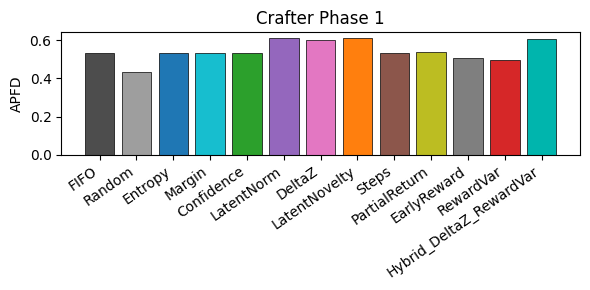

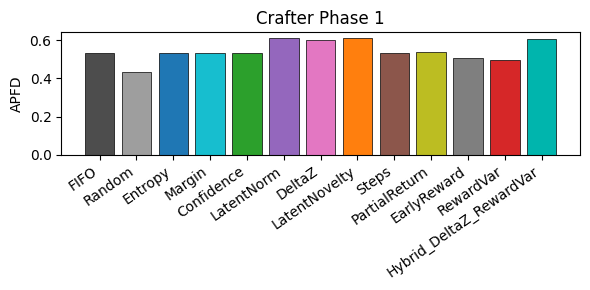

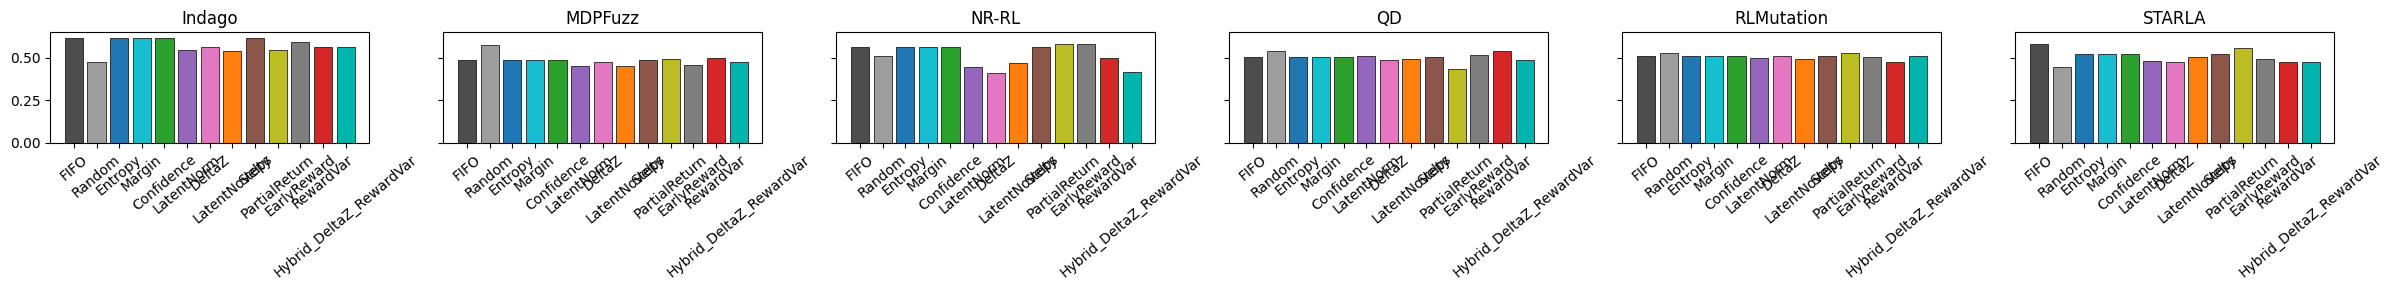


Tables : /content/drive/MyDrive/mbrl-testing-frameworks-empirical-study/results/Crafter/tables
Figures: /content/drive/MyDrive/mbrl-testing-frameworks-empirical-study/results/Crafter/figs


In [ ]:
def main():

    print("=" * 70)
    print("CRAFTER TCP REPLICATION")
    print("=" * 70)

    print("\nRunning Phase 1...")

    phase1_results = (
        run_phase1()
    )

    phase1_agg = (
        summarize_phase1(
            phase1_results
        )
    )

    phase1_stats = (
        phase1_statistics(
            phase1_results
        )
    )

    print("\nRunning Phase 2...")

    phase2_results = (
        run_phase2()
    )

    phase2_agg = (
        summarize_phase2(
            phase2_results
        )
    )

    phase2_stats = (
        phase2_statistics(
            phase2_results
        )
    )

    print("\nGenerating plots...")

    plot_phase1_apfd(
        phase1_agg
    )

    plot_phase1_apfd(
        phase1_agg
    )

    plot_phase2_apfd(
        phase2_agg
    )

    print(
        f"\nTables : {TABLES_DIR}"
    )

    print(
        f"Figures: {FIGS_DIR}"
    )

    return {

        "phase1_results":
            phase1_results,

        "phase1_agg":
            phase1_agg,

        "phase1_stats":
            phase1_stats,

        "phase2_results":
            phase2_results,

        "phase2_agg":
            phase2_agg,

        "phase2_stats":
            phase2_stats,
    }


if __name__ == "__main__":

    outputs = main()